In [2]:
import sys
import os

sys.path.append(os.path.join(os.getcwd(), "..", "reinforce-the-puck"))

import tueplots
import numpy as np
import pandas as pd
from components.memory import (
    Memory,
    BalancedMemory,
    PrioritizedMemory,
    BalancedPrioritizedMemory,
)


# from tueplots import bundles

# plt.rcParams.update({"figure.dpi": 175})
# plt.rcParams.update(bundles.neurips2024(family="sans-serif"))
# plt.rcParams.update(
#     {
#         "font.size": 10,
#         "xtick.labelsize": 10,
#         "ytick.labelsize": 10,
#         "axes.labelsize": 12,
#         "axes.titlesize": 12,
#         "legend.fontsize": 10,
#         "legend.title_fontsize": 12,
#     }
# )
import matplotlib.pyplot as plt

In [3]:
# CONSTANTS
BUFFER_SIZE = 100000
NUM_ITERATIONS = 100000
NUM_SAMPLES = 100
EVAL_AT = 10

# Simulate prob. per buffer type
buffer = Memory(BUFFER_SIZE)
buffer_balanced = BalancedMemory(BUFFER_SIZE)
buffer_prioritized = PrioritizedMemory(BUFFER_SIZE, decay_steps=NUM_ITERATIONS)
buffer_balanced_prioritized = BalancedPrioritizedMemory(BUFFER_SIZE)
samples = pd.DataFrame(columns=["buffer_type", "sample", "iteration"])

In [4]:
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm
import pandas as pd

import os


# Function to handle operations for a specific buffer
def process_buffer(buffer_name, buffer, n_iterations, n_samples, eval_at):
    local_results = []
    choices = [i for i in range(-10, 10)]
    for i in range(n_iterations):
        if buffer_name == "BalancedPrioritizedMemory":
            buffer.add_transition([i, 1, 1, np.random.choice(choices)])
        else:
            buffer.add_transition([i])

        if i % eval_at == 0:
            sample_size = min(n_samples, i + 1)
            batch_samples = buffer.sample(sample_size)

            if buffer_name == "PrioritizedMemory":
                batch, idxs, priorities = batch_samples
                td_errors = np.random.choice(choices, size=sample_size)
                buffer.update_priorities(idxs, td_errors, td_errors)
                for sample, idx, prio in zip(batch, idxs, priorities):
                    local_results.append(
                        {
                            "Buffer": buffer_name,
                            "Sample": (sample[0]),
                            "Priority": prio,
                            "Index": i,
                        }
                    )
            elif buffer_name == "BalancedPrioritizedMemory":
                batch, idxs, priorities = batch_samples
                for sample, idx, prio in zip(batch, idxs, priorities):
                    local_results.append(
                        {
                            "Buffer": buffer_name,
                            "Sample": (sample[0]),
                            "Priority": prio,
                            "Index": i,
                        }
                    )
            else:
                for sample in batch_samples:
                    local_results.append(
                        {
                            "Buffer": buffer_name,
                            "Sample": (sample[0]),
                            "Priority": 1,
                            "Index": i,
                        }
                    )

        if i % (n_iterations * 0.1) == 0:
            print(
                f"Buffer {buffer_name} at {i} of {n_iterations} ({i/n_iterations*100:.2f}%)"
            )
    return pd.DataFrame(local_results)


# Define buffers and their names
buffers = {
    "Memory": buffer,
    "BalancedMemory": buffer_balanced,
    "PrioritizedMemory": buffer_prioritized,
    "BalancedPrioritizedMemory": buffer_balanced_prioritized,
}

final_df = pd.DataFrame()
if os.path.exists("samples.csv"):
    final_df = pd.read_csv("samples.csv")
else:
    # Use ProcessPoolExecutor for parallel processing
    with ProcessPoolExecutor() as executor:
        futures = {
            executor.submit(
                process_buffer, buffer_name, b, NUM_ITERATIONS, NUM_SAMPLES, EVAL_AT
            ): buffer_name
            for buffer_name, b in buffers.items()
        }

        # Use tqdm to track progress
        results = []
        for future in tqdm(futures, desc="Processing Buffers"):
            results.append(future.result())

    # Combine all DataFrames into a single DataFrame
    final_df = pd.concat(results, ignore_index=True)
samples = final_df.copy()
samples

,Buffer,Sample,Priority,Index
0,Memory,0,1.000000,0
1,Memory,2,1.000000,10
2,Memory,9,1.000000,10
3,Memory,2,1.000000,10
4,Memory,2,1.000000,10
...,...,...,...,...
3997835,BalancedPrioritizedMemory,70701,0.426020,99990
3997836,BalancedPrioritizedMemory,55779,0.415515,99990
3997837,BalancedPrioritizedMemory,62399,0.366463,99990
3997838,BalancedPrioritizedMemory,19919,1.000000,99990


In [5]:
samples.to_csv("samples.csv", index=False)

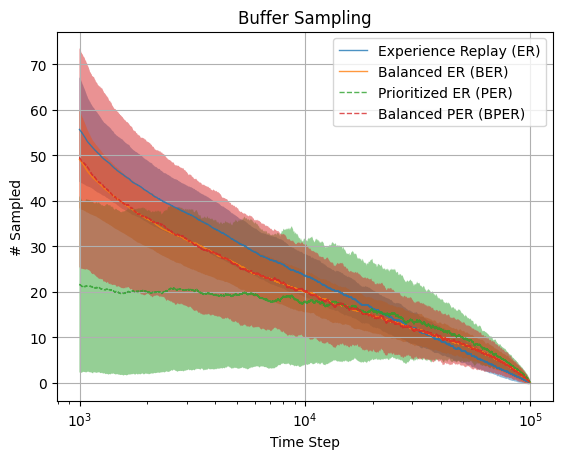

In [11]:
# Plot
fig, ax = plt.subplots(1, 1)
buffers_to_plot = [
    "Memory",
    "BalancedMemory",
    "PrioritizedMemory",
    "BalancedPrioritizedMemory",
]
type2name = {
    "Memory": "Experience Replay (ER)",
    "BalancedMemory": "Balanced ER (BER)",
    "PrioritizedMemory": "Prioritized ER (PER)",
    "BalancedPrioritizedMemory": "Balanced PER (BPER)",
}
for buffer_type in buffers_to_plot:
    data = samples[samples["Buffer"] == buffer_type]
    s = data["Sample"]
    i = data["Index"]

    # Compute how often which sample was selected
    sample_counts = s.value_counts()
    sample_counts = sample_counts.reindex(range(NUM_ITERATIONS))
    sample_counts = sample_counts.fillna(0)

    # Plot moving average
    sample_counts_ma = sample_counts.rolling(window=1000).mean()
    style = "--" if "Prioritized" in buffer_type else "-"
    ax.plot(
        sample_counts_ma,
        label=f"{type2name[buffer_type]}",
        linewidth=1,
        alpha=0.8,
        linestyle=style,
    )

    # Plot the confidence interval
    sample_counts_ms = sample_counts.rolling(window=1000).std()
    ax.fill_between(
        sample_counts_ma.index,
        sample_counts_ma - sample_counts_ms,
        sample_counts_ma + sample_counts_ms,
        alpha=0.5,
    )


ax.set_xlabel("Time Step")
ax.set_ylabel("# Sampled")
ax.set_title("Buffer Sampling")
# Logscale
# ax.set_yscale("log")
ax.set_xscale("log")
ax.grid()
ax.legend()
# plt.legend()
plt.show()

Test Balanced

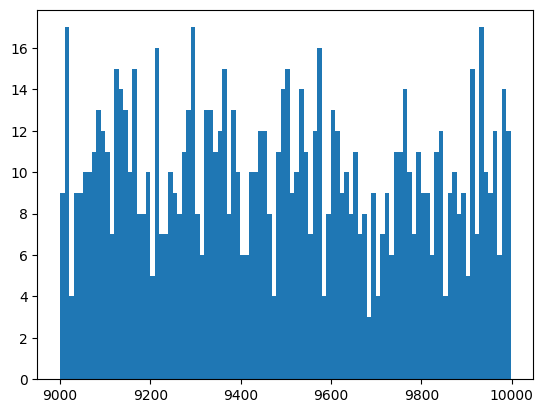

In [7]:
b = PrioritizedMemory(1000)

for i in range(10000):
    b.add_transition([i])


# strength = b.memory_strength[: b.size]
# probs = strength / (strength.sum())

# Get argmax of memory strength
# argmax = np.argmax(strength)
# b.transitions[argmax], argmax, strength[argmax]

sample = b.sample(1000)

plt.figure()
plt.hist([s[0] for s in sample[0]], bins=100)
plt.show()

# Plot probabilities
# probs, strength